In [381]:
# This Notebook is used to analyse the noise performances of the DRE from data files


In [382]:
# imports
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt
import os
import readData as rddt
import constants as cst
import general_tools as gt
from scipy.optimize import curve_fit


In [383]:
path = '/Users/laurent/data/TestPlan21-perfo/20241031_150830_errorBandShape-col2'


In [384]:
# Parameters for the spectral analysis. The unit seems to be per sqrt(Hz). I don't know why...
xlabel = r'Frequencies $(Hz)$'
#ylabel = r'Noise $\left(V_{rms} /\sqrt{Hz}\right)$'
ylabel = r'Error signal $\left(dBm / \sqrt{Hz} \right)$'
scaling = 'spectrum'
#scaling = 'density'
ymin, ymax = -100, -75
xmin, xmax = 1e5, 1e8

In [385]:
def NoisePowerDensity(voltage, fs, nSamples = 2**16, verbose=False):

    # Slicing the data in several records
    nRecords = int(len(voltage)/nSamples) * 2 -1

    xf, dsp = signal.periodogram(voltage[:nSamples], fs, scaling=scaling)

    for record in range(nRecords-1):
        sig = voltage[int((record+1)*nSamples/2):int((record+3)*nSamples/2)]
        _, dspi = signal.periodogram(sig, fs, scaling=scaling)
        dsp += dspi
    dsp /= nRecords

    rmsInTime = voltage.std()
    rmsInFreq = np.sqrt(dsp[1:].sum())
    if verbose:
        print("rms in time: ", rmsInTime)
        print("rms in frequencies: ", rmsInFreq)
        
    # rmsInTime = Sigma (dsp[1:]) then dsp should be normalized
    # print("/BEFORE/ ", rmsInTime, "   ", np.sqrt(dsp[-10]*fs/2))
    dsp = dsp * len(dsp) / (fs / 2)
    # print("/AFTER/ ", rmsInTime, "   ", np.sqrt(dsp[-10]*fs/2))

    return xf, dsp, rmsInTime, rmsInFreq

In [386]:
def NoisePowerDensityFromDumps(path, colId, verbose=False):

    npts = cst.nSamplesPerRow*cst.muxFactor

    files = [f for f in os.listdir(path) \
                    if os.path.isfile(os.path.join(path, f)) \
                    and f[-5:]==".fits" and f[:5]=="dump_"]
    
    nFiles = len(files)
    print("Processing {0:} files".format(nFiles))

    WelchFactor = 1
    dspDumps = np.zeros((int(npts/(2*WelchFactor))+1))
    for index, file in enumerate(files):
        if verbose:
            print("Processing science file {0:}".format(index), file)
        columns, errors = rddt.readDumpFile(os.path.join(path, file))
        
        # Converting data in engineering values
        voltage = columns[colId] * cst.fsrAdcError / 2**cst.nBitsAdcErrInDumps
        
        xf, dsp, rmsInTime, rmsInFreq = NoisePowerDensity(voltage, cst.fSamp, int(cst.muxFactor*cst.nSamplesPerRow/WelchFactor), verbose)
        dspDumps += dsp
    
    dspDumps /= len(files)
    
    return xf, dspDumps, rmsInTime, rmsInFreq

In [387]:
# Modèle de la fonction de transfert en dB pour un filtre passe-bas de premier ordre 
def low_pass_filter_order_1(f, fc):
    return - 10 * np.log10(1 + (f / fc) ** 2)

# Modèle de la fonction de transfert en dB pour un filtre passe-bas de premier ordre avec amplitude basse fréquence
def low_pass_filter_with_amplitude(f, A_db, fc):
    return A_db - 10 * np.log10(1 + (f / fc) ** 2)

# Modèle de la fonction de transfert en dB pour un filtre passe-bas d'ordre 2 avec amplitude basse fréquence
def low_pass_filter_order_2(f, A_db, fc, Q):
    return A_db - 10 * np.log10(1 + (f / fc)**(2 * Q))

# Conversion de Vrms vers dBm
def volts_to_dBm(v_rms, impedance=50):
    return 20 * np.log10(v_rms) + 10 * np.log10(1 / (impedance * 0.001))

In [388]:
# Plotting noise spectral density for one column
def pltNspOneCol(path, colId, verbose=False):

    dataDirname = "dmx_data"
    pathData = os.path.join(path, dataDirname)
    
    plotDirname = "PLOTS"
    pathPlot = os.path.join(path, plotDirname)
    gt.createdir(pathPlot)
    plotFileName = os.path.join(pathPlot, 'adcBandShape_col{0:}.png'.format(colId))
    
    plot_dc_level = False # If True a line is added on the plot at the low frequency level
   
    # Doing plot
    fig = plt.figure(figsize=(8, 6))
    title = path.split('/')[-1][:-5] + " Column {0:}".format(colId)
    ax = fig.add_subplot(1,1,1)
    
    # Processing dumps
    xfDump, dspDumps, _, _ = NoisePowerDensityFromDumps(pathData, colId, verbose)
    dsnDumps = np.sqrt(dspDumps)
    dsnDumps_dBm = volts_to_dBm(dsnDumps)

    ax.semilogx(xfDump[1:], dsnDumps_dBm[1:], color='k', label='Error signal spectrum')

    # Ajustement de la courbe pour estimer la fréquence de coupure (fc) en imposant l'amplitude
    idcLimit = 60
    dc = volts_to_dBm(dsnDumps[1:idcLimit].mean())
    dsnDumps2_dB = volts_to_dBm(dsnDumps) - dc
    popt3, pcov3 = curve_fit(low_pass_filter_order_1, xfDump, dsnDumps2_dB, p0=[20e6])  # p0=[fc initial]
    fc_estime3 = popt3
    # Affichage des résultats
    print(f"Fréquence de coupure estimée : {fc_estime3[0]:.2f} Hz")
    # Tracé des données et de l'ajustement
    frequencies_fit3 = np.linspace(xmin, xmax, 500)
    magnitudes_fit3 = low_pass_filter_order_1(frequencies_fit3, fc_estime3) + dc
    lbl = '1rst order LPF fit (fc = {0:4.2f} MHz)'.format(fc_estime3[0]/1e6)
    ax.semilogx(frequencies_fit3, magnitudes_fit3, '--', linewidth=2, color='blue', label=lbl)
    
    # tracé des niveaux DC et -3dB
    if (plot_dc_level):
        idcLimit = 60
        dc = volts_to_dBm(dsnDumps[1:idcLimit].mean())
        ax.semilogx([xfDump[1], xfDump[idcLimit]], [dc, dc], '--', linewidth=2, color='blue', label='DC level')
        ax.semilogx([xfDump[1], xfDump[-1]], [dc-3, dc-3], '--', linewidth=1, color='blue', label='DC level -3dB')
    
    ax.set_xlim([xmin, xmax])
    ax.set_ylim([ymin, ymax])
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel(xlabel)
    ax.grid()
    ax.legend(loc='best')
    plt.savefig(plotFileName, dpi=300, bbox_inches='tight')


Processing 32 files
Fréquence de coupure estimée : 17001039.41 Hz


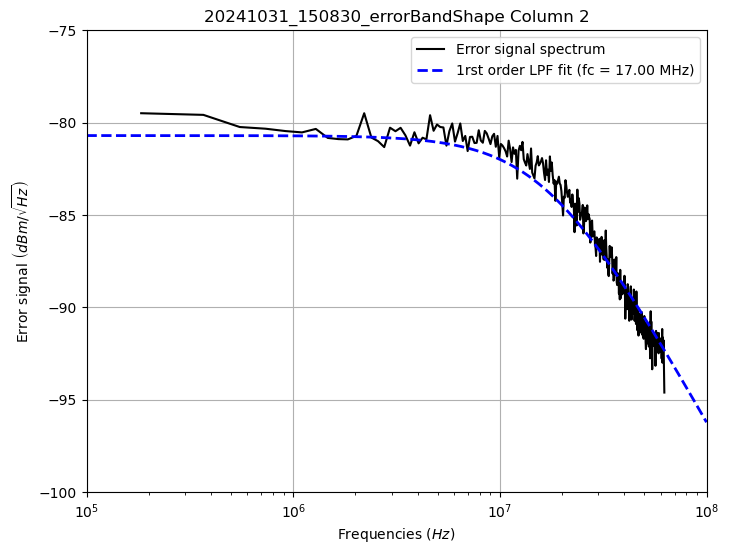

In [389]:
pltNspOneCol(path, 2)